In [1]:
!pip install PyMuPDF==1.26.1

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


# 1. На предыдущем занятии по обработке документов

Используем первые шаги по обработке документов из занятия «Анализ и подготовка документов». Там мы рассматривали, как с помощью разных библиотек в Python можно обрабатывать PDF-документы, извлекать необходимую информацию и дальше работать с ней, как с текстом.

**Компоненты:**  
* PDF-документ на выбор.
* Модель для создания эмбеддингов на выбор.

**Шаги:**  
1. Импортировать PDF-документ.
2. Обработать текст для эмбеддингов (например, разбить на предложения/фрагменты). Текст разбивается на логические части (чанки) для эффективного моделирования.
3. Создать эмбеддинги для текстовых фрагментов с помощью выбранной модели. Используются современные модели (например, BERT, Sentence-BERT, GPT-Embeddings).  
4. Сохранить эмбеддинги в файл для последующего использования  
*(эмбеддинги будут храниться годами или до потери жесткого диска)*. Рекомендуемые форматы хранения: `.npy`, `.h5`, `.pt` (PyTorch).

## Импорт PDF-документов  
Этот подход работает с разными типами документов. Мы начнем с PDF из-за популярности формата.  

**Важно:** метод также поддерживает:  
- Текстовые файлы (.txt)  
- Цепочки писем (email threads)  
- Техническую документацию  
- Статьи и научные работы  

**Пример использования:**  
Представим, что мы студенты-диетологи Гавайского университета, изучающие открытый учебник [*«Питание человека: издание 2020 года»*](https://pressbooks.oer.hawaii.edu/humannutrition2/).    

In [2]:
import os

pdf_path = "Глубокое обучение.pdf"

assert os.path.exists(pdf_path), f"Файл {pdf_path} не найден"
print(f"Файл {pdf_path} найден.")

Файл Глубокое обучение.pdf найден.


**PDF успешно загружен!**

Мы можем преобразовать страницы PDF в текстовый формат, выполнив шаги:  
1. Определить путь к PDF-файлу.  
2. Открыть и прочитать его с помощью библиотеки **PyMuPDF** (используется через `import fitz`).

**Процесс обработки:**  
- Создайте **вспомогательную функцию** для предобработки текста во время чтения.  
- Обратите внимание: текст может считываться неоднородно (например, разное форматирование таблиц/текста), что требует адаптивной обработки.  

**Структура данных:**  
Каждая страница сохраняется в виде словаря, который затем добавляется в список для удобства дальнейшего использования.  

Пример структуры словаря:  
```python
{
    "page_number": 1,
    "text": "Содержание страницы...",
    "metadata": {"автор": "Иван Петров"}
}
```

In [3]:


# Требуется установка PyMuPDF: !pip install PyMuPDF (репозиторий: https://github.com/pymupdf/pymupdf)
# Примечание: библиотека использует лицензию AGPL-3.0 (учитывайте при коммерческом использовании кода)
import fitz  # pymupdf (выбрана вместо pypdf для нашего кейса)
from tqdm.auto import tqdm  # индикатор выполнения, установка: !pip install tqdm


def text_formatter(text: str) -> str:
    """Выполняет базовое форматирование текста."""
    cleaned_text = text.replace("\n", " ").strip()  # примечание: обработка может отличаться для разных документов
    return cleaned_text  # сюда можно добавить другие функции форматирования


# Чтение PDF и извлечение текста/страниц
# Примечание: работает только с текстом (изображения/графики игнорируются)
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Открывает PDF-файл и извлекает текст со страниц со сбором статистики.

    Параметры:
        pdf_path (str): Путь к PDF-документу

    Возвращает:
        list[dict]: Список словарей с данными для каждой страницы:
            - page_number: номер страницы (с коррекцией)
            - page_char_count: количество символов
            - page_word_count: количество слов
            - page_sentence_count_raw: примерное количество предложений
            - page_token_count: оценка токенов (1 токен ≈ 4 символа)
            - text: обработанный текст страницы
    """
    doc = fitz.open(pdf_path)  # открываем документ
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # итерируем страницы с прогресс-баром
        text = page.get_text()  # получаем текст в UTF-8
        text = text_formatter(text)
        pages_and_texts.append({
            "page_number": page_number - 41,  # коррекция нумерации (PDF начинается с 42 стр.)
            "page_char_count": len(text),
            "page_word_count": len(text.split(" ")),
            "page_sentence_count_raw": len(text.split(". ")),
            "page_token_count": len(text) // 4,  # расчет токенов: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
            "text": text
        })
    return pages_and_texts


pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]  # просмотр первых двух элементов

0it [00:00, ?it/s]

[{'page_number': -41,
  'page_char_count': 2582,
  'page_word_count': 331,
  'page_sentence_count_raw': 20,
  'page_token_count': 645,
  'text': 'Интернет\ue02dмагазин: www.dmkpress.com Книга – почтой: e\ue02dmail: orders@alians-kniga.ru Оптовая продажа:  «Альянс\ue02dкнига» Тел./факс: (499) 782\ue02d3889 e\ue02dmail: books@alians-kniga.ru www.дмк.рф Глубокое обучение — это вид машинного обучения, наделяющий компьютеры  способностью учиться на опыте. Книга содержит математические и концептуальные  основы линейной алгебры, теории вероятностей и теории информации, численных  расчетов и машинного обучения в том объеме, который необходим для понимания  материала. Описываются приемы глубокого обучения, применяемые на практике, в том  числе глубокие сети прямого распространения, регуляризация, алгоритмы оптимизации,  сверточные сети, моделирование последовательностей и др. Рассматриваются такие  приложения, как обработка естественных языков, распознавание речи, компьютерное  зрение, онлайнов

Теперь возьмем случайную выборку страниц.

In [4]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 255,
  'page_char_count': 3203,
  'page_word_count': 441,
  'page_sentence_count_raw': 28,
  'page_token_count': 800,
  'text': '296\u2003 \uf076\u2003 Сверточные сети красной, зеленой и\xa0синей компонент. В\xa0многослойной сверточной сети входом второго  слоя является выход первого, который обычно состоит из результатов многих разных  сверток в\xa0каждой позиции. При работе с\xa0изображениями мы обычно интерпретируем  вход и\xa0выход свертки как трехмерные тензоры, в\xa0которых по одному измерению на- ходятся цветовые каналы, а\xa0по двум другим\xa0– пространственные координаты каналов.  Программные реализации обычно работают в\xa0пакетном режиме, так что на самом деле  используются четырехмерные тензоры, в\xa0которых четвертая ось соответствует приме- рам в\xa0пакете, но в\xa0нашем описании мы для простоты будем эту ось опускать. Поскольку в\xa0сверточных сетях свертка обычно применяется к\xa0нескольким кана- лам, коммутативность соответствующих операций не гарантир

## Получение статистики по текстам

Проведем предварительный анализ данных (EDA), чтобы понять объем текста, количество символов, слов и так далее. Это поможет определить оптимальный способ их разбиения.

Многие модели для создания эмбеддингов имеют ограничения на длину входных текстов. Например, модель [`all-mpnet-base-v2`](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) из библиотеки [`sentence-transformers`](https://www.sbert.net/docs/pretrained_models.html) принимает максимум **384 токена**.
  
Это означает, что модель обучена работать с текстами длиной до 384 токенов (где: 1 токен ≈ 4 символа ≈ 0.75 слова).

Тексты длиннее 384 токенов будут автоматически обрезаться при обработке этой моделью, что может привести к потере информации.

Более подробно мы обсудим это в разделе про создание эмбеддингов.

А сейчас преобразуем наш список словарей в `DataFrame` и проанализируем его.

In [5]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,-41,2582,331,20,645,Интернетмагазин: www.dmkpress.com Книга – поч...
1,-40,61,8,1,15,"Ян Гудфеллоу, Иошуа Бенджио, Аарон Курвилль Гл..."
2,-39,115,15,1,28,"Ian Goodfellow, Yoshua Bengio, Aaron Courville..."
3,-38,112,15,1,28,"Ян Гудфеллоу, Иошуа Бенджио, Аарон Курвилль Гл..."
4,-37,1916,254,18,479,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд..."


In [6]:
# Статистика
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,653.00,653.00,653.00,653.00,653.00
mean,285.00,2759.54,364.75,26.27,689.49
std,188.65,728.07,93.57,21.45,182.02
min,-41.00,61.00,8.00,1.00,15.00
25%,122.00,2324.00,307.00,17.00,581.00
50%,285.00,2850.00,375.00,22.00,712.00
75%,448.00,3321.00,440.00,26.00,830.00
max,611.00,5307.00,528.00,120.00,1326.00


По этим данным среднее количество токенов на страницу составляет 287.

Это означает, что для нашего случая можно использовать модель `all-mpnet-base-v2` (с максимальной длиной входа 384 токена) для создания эмбеддингов целых страниц без обрезки.

## Дальнейшая обработка текста (разбиение страниц на предложения)  
Идеальный способ предобработки текста перед созданием эмбеддингов все еще является предметом исследований.  

**Простой рабочий метод:** разбивать текст на группы предложений (чанки) по 5, 7, 10 или более предложений. Эти значения можно настраивать под ваши задачи.  



### Общий рабочий процесс:  
1. Загрузить текст.  
2. Разделить на чанки.  
3. Создать эмбеддинги для чанков.  
4. Использовать эмбеддинги.



### Методы разбиения на предложения:  
- **Базовый:** Разделение по `. ` (например, `text.split(". ")`, как делали ранее).
- **Продвинутый:** Использование NLP-библиотек (spaCy, nltk).  



### Зачем разбивать на предложения?  
- Упрощение обработки (особенно для плотных текстов).  
- Возможность точно определить, **какие предложения** повлияли на результат в RAG-пайплайне.



**Рекомендация:** используйте spaCy для разбиения, так как это надежнее, чем простое разделение по `. `.

In [7]:
# Импорт английского языка для spaCy (инструкции по установке: https://spacy.io/usage)
from spacy.lang.en import English

# Создаем объект NLP для английского языка
nlp = English()

# Добавляем компонент sentencizer в пайплайн (документация: https://spacy.io/api/sentencizer/)
nlp.add_pipe("sentencizer")

# Создаем пример документа для тестирования
doc = nlp("This is a sentence. This another sentence.")
assert len(list(doc.sents)) == 2  # Проверяем, что текст разбит на 2 предложения

# Получаем и выводим список предложений документа
list(doc.sents)

[This is a sentence., This another sentence.]

Необязательно использовать spaCy, однако это библиотека с открытым исходным кодом, специально созданная для масштабной обработки NLP-задач, таких как наша.  

Давайте применим наш небольшой **пайплайн для разбиения на предложения** к текстовым страницам.

In [8]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Проверяем что все предложения это строки
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    # Считаем предложения
    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/653 [00:00<?, ?it/s]

In [9]:
# Проверим
random.sample(pages_and_texts, k=1)

[{'page_number': -5,
  'page_char_count': 3137,
  'page_word_count': 414,
  'page_sentence_count_raw': 22,
  'page_token_count': 784,
  'text': '36\u2003 \uf076\u2003 Введение 1.2.2. Увеличение размера набора данных Может возникнуть вопрос, почему лишь недавно была осознана роль глубокого  обуче\xadния как ключевой технологии, хотя первые эксперименты с\xa0искусственными  нейронными сетями были проведены еще в\xa01950-х годах. Глубинное обучение успеш- но применяется в\xa0коммерческих приложениях, начиная с\xa01990-х, но часто его рассмат\xad ривали не как технологию, а\xa0как искусство\xa0– как нечто такое, что подвластно только  экспертам. Так было до недавнего времени. Действительно, чтобы добиться хорошего  качества от алгоритма глубокого обучения, нужен некоторый навык. Но, к\xa0счастью,  потребность в\xa0таком навыке снижается по мере увеличения объема обучаю\xadщих дан- ных. Алгоритмы обучения, по качеству приближающиеся к\xa0возможностям челове- ка при решении сложных задач, ос

Отлично! Теперь преобразуем наш список словарей в DataFrame и получим статистические данные.

In [10]:
import pandas as pd


df = pd.DataFrame(pages_and_texts)

Похоже, что для нашего набора текстов грубый подсчет предложений (например, разделение по `". "`) довольно близок к тому, что показал spaCy.

Теперь, когда у нас есть текст, разделенный на предложения, давайте сгруппируем эти предложения.

## Группировка предложений

Давайте сделаем шаг к разбиению нашего списка предложений или текста на мелкие части.

Как вы могли догадаться, этот процесс называется **чанкинг** (группировка).

### Почему мы это делаем?

1. Легче управлять частями текста похожего размера.
2. Не перегружать емкость моделей для создания эмбеддингов токенами (например, если модель для создания эмбеддингов имеет емкость 384 токена, может произойти потеря информации, если вы попытаетесь создать эмбеддинг для последовательности из 400+ токенов).
3. Наше окно контекста LLM (количество токенов, которое LLM может обработать) может быть ограничено и требует вычислительной мощности, поэтому мы хотим убедиться, что используем его максимально эффективно.

**На заметку**: существует множество способов для создания частей текста.

Пока мы будем держаться простого подхода и разобьем наши страницы с предложениями на группы по 10 (это число произвольное и может быть изменено, я выбрал его потому, что оно хорошо соответствует емкости нашей модели для создания эмбеддингов в 384 токена).

В среднем каждая из наших страниц содержит 10 предложений.

И в среднем 287 токенов на страницу.

Таким образом, наши группы по 10 предложений также будут длиной около 287 токенов.

Это дает нам достаточно места для создания эмбеддингов текста с помощью нашей модели `all-mpnet-base-v2` (емкость модели — 384 токена).

Чтобы разделить наши группы предложений на части по 10 или меньше, давайте создадим функцию, которая принимает список на вход и рекурсивно разбивает его на подсписки указанного размера.

In [11]:
# Определим размер разделения для преобразования групп предложений в чанки
num_sentence_chunk_size = 10

# Создадим функцию, которая рекурсивно разбивает список на нужные размеры
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Разбивает input_list на подсписки размером slice_size (или максимально близко к этому).

    Например, список из 17 предложений будет разбит на два списка [[10], [7]]
    """
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Перебираем страницы и тексты и разбиваем предложения на чанки
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/653 [00:00<?, ?it/s]

In [12]:
# Возьмем пример из группы (примечание: многие примеры имеют только 1 чанк, так как у них <=10 предложений всего)
random.sample(pages_and_texts, k=1)

[{'page_number': 432,
  'page_char_count': 2822,
  'page_word_count': 367,
  'page_sentence_count_raw': 27,
  'page_token_count': 705,
  'text': 'Применение графов для описания структуры\xa0модели\u2003 \uf076\u2003 473 Структурные вероятностные модели предлагают формальную систему моделиро- вания только прямых взаимодействий между случайными величинами. Это позволя- ет обойтись значительно меньшим числом параметров модели и, следовательно, по- лучить надежную оценку при меньшем объеме данных. Уменьшение размера модели  также кардинально снижает вычислительную стоимость с\xa0точки зрения памяти для  хранения модели, времени выполнения вывода и\xa0выборки из модели. 16.2. Применение графов для описания  структуры\xa0 модели В структурных вероятностных моделях для представления взаимодействий между  случайными величинами применяются графы. Вершины представляют случайные  величины, а\xa0ребра\xa0– прямые взаимодействия. Прямые взаимодействия подразумева- ют также наличие косвенных, но явн

In [13]:
# Создадим DataFrame для получения статистики
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,653.00,653.00,653.00,653.00,653.00,653.00,653.00
mean,285.00,2759.54,364.75,26.27,689.49,25.45,2.99
std,188.65,728.07,93.57,21.45,182.02,16.37,1.65
min,-41.00,61.00,8.00,1.00,15.00,1.00,1.00
25%,122.00,2324.00,307.00,17.00,581.00,17.00,2.00
50%,285.00,2850.00,375.00,22.00,712.00,23.00,3.00
75%,448.00,3321.00,440.00,26.00,830.00,27.00,3.00
max,611.00,5307.00,528.00,120.00,1326.00,96.00,10.00


Обратите внимание, что среднее количество чанков составляет около 1.5. Это ожидаемо, так как многие из наших страниц содержат в среднем только 10 предложений.

## Разделение каждого чанка на отдельный элемент

Мы хотим преобразовать каждый чанк предложений в его собственное числовое представление.

Чтобы сохранить порядок, давайте создадим новый список словарей, где каждый словарь будет содержать один чанк предложений вместе с соответствующей информацией (такой как номер страницы), а также статистику о каждом чанке.

In [14]:
import re

# Разделяем каждый чанк на отдельный элемент
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Объединяем предложения в структуру абзаца, т.е. чанк (таким образом, они являются одной строкой)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" для любой комбинации точки и заглавной буквы
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Получаем статистику о чанке
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        pages_and_chunks.append(chunk_dict)

# Сколько у нас чанков?
len(pages_and_chunks)

  0%|          | 0/653 [00:00<?, ?it/s]

1955

In [15]:
# Посмотрим на случайный образец
random.sample(pages_and_chunks, k=1)

[{'page_number': 336,
  'sentence_chunk': 'Такие большие модели обучают некоторую функцию f(x), но используют при этом гораздо больше параметров, чем необходимо для решения задачи.Их размер велик только потому, что число обучающих примеров ограничено.После того как функция f(x) аппроксимирована, мы можем сгенерировать обучающий набор, содержащий бесконечно много примеров, просто применив f к\xa0случайной выборке x. Затем мы обуча\xadем новую, меньшую модель, так чтобы она совпадала с\xa0f(x) на этой выборке. Чтобы емкость новой модели использовалась наиболее эффективно, лучше выбирать новые точки x из распределения, похожего на реальные тестовые данные, которые бу- дут предъявлены модели впоследствии.Это можно сделать, слегка исказив обучаю\xad щие примеры или произведя выборку из порождающей модели, обученной на исход- ном обучающем наборе.Альтернативно можно обучить меньшую модель только на исходных обучающих примерах, но научить ее копировать другие признаки модели, например апостер

Отлично!

Теперь мы разбили весь наш учебник на чанки по 10 предложений или меньше, а также сохранили номер страницы, из которой они взяты.

Это означает, что мы можем ссылаться на чанк текста и знать его источник.

Давайте получим статистику по нашим чанкам.

In [16]:
# Получаем статистику о наших чанках
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,1955.00,1955.00,1955.00,1955.00
mean,320.21,909.30,110.12,227.32
std,201.94,478.75,58.90,119.69
min,-41.00,4.00,1.00,1.00
25%,143.50,451.00,58.00,112.75
50%,327.00,970.00,114.00,242.50
75%,519.00,1258.00,153.00,314.50
max,611.00,3310.00,451.00,827.50


Хм, похоже, что некоторые из наших чанков имеют довольно низкое количество токенов.

Давайте проверим примеры с менее чем 30 токенами (примерно длина предложения) и посмотрим, стоит ли их сохранять.

In [17]:
# Покажем случайные чанки с длиной менее 30 токенов
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(5).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 7.0 | Text: 2014; Bahdanau et al.,2015).
Chunk token count: 12.25 | Text: Linear and Nonlinear Programming. Addison Wesley.
Chunk token count: 24.0 | Text: 2014), то модель сможет обучиться отличным признакам для классификатора в случае, когда помечен-
Chunk token count: 20.0 | Text: 504.	 Minsky, M. L. and Papert, S. A. (1969). Perceptrons. MIT Press, Cambridge.
Chunk token count: 26.75 | Text: Обзор состояния дел в области статистики естественных изображений имеется в работе Hyvärinen et al. (2009).


Похоже, что многие из них являются заголовками и подписями разных страниц.

И они не содержат много полезной информации.

Давайте отфильтруем наш DataFrame/список словарей, чтобы включить только чанки с длиной более 30 токенов.

In [18]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': -41,
  'sentence_chunk': 'Интернет\ue02dмагазин: www.dmkpress.com Книга – почтой: e\ue02dmail: orders@alians-kniga.ru Оптовая продажа: «Альянс\ue02dкнига» Тел./факс: (499) 782\ue02d3889 e\ue02dmail: books@alians-kniga.ru www.дмк.рф Глубокое обучение — это вид машинного обучения, наделяющий компьютеры способностью учиться на опыте.Книга содержит математические и концептуальные основы линейной алгебры, теории вероятностей и теории информации, численных расчетов и машинного обучения в том объеме, который необходим для понимания материала.Описываются приемы глубокого обучения, применяемые на практике, в том числе глубокие сети прямого распространения, регуляризация, алгоритмы оптимизации, сверточные сети, моделирование последовательностей и др.Рассматриваются такие приложения, как обработка естественных языков, распознавание речи, компьютерное зрение, онлайновые рекомендательные системы, биоинформатика и видеоигры. Наконец, описываются перспективные направления исследовани

Меньшие чанки отфильтрованы!

Пришло время создать эмбеддинги для наших чанков текста!

# 2. Векторное представление текстовых фрагментов

Люди понимают текст, а машины лучше работают с числами.  

**Эмбеддинг** (embedding) — это общая концепция, но одно из моих любимых простых определений: *«полезное числовое представление»*. Главная особенность современных эмбеддингов в том, что они являются **обучаемыми представлениями**. Это означает, что вместо прямой замены слов/токенов/символов на числа (например, `{"a": 0, "b": 1, "c": 3...}`) числовое представление токенов формируется в процессе обучения на больших текстовых корпусах, где модель анализирует взаимосвязи между ними. В идеале эмбеддинги текста должны отражать смысловую близость: похожие по смыслу фрагменты будут иметь похожие числовые представления.  

> **Примечание:** Большинство современных NLP-моделей работают с «токенами», которые могут представлять собой комбинации символов или частей слов, а не целые слова. Например, строка `"hello world!"` с использованием байт-парного кодирования (BPE через библиотеку OpenAI [`tiktoken`](https://github.com/openai/tiktoken)) преобразуется в токены `{15339: b'hello', 1917: b' world', 0: b'!'}`. У Google есть собственная библиотека токенизации — [SentencePiece](https://github.com/google/sentencepiece).  

**Наша цель** — преобразовать каждый текстовый фрагмент в числовое представление (вектор эмбеддинга, где вектор — это упорядоченная последовательность чисел).  

После преобразования текста в векторы люди не смогут их интерпретировать, но это и не нужно. Эмбеддинги предназначены для машин. С их помощью компьютеры находят паттерны в данных, а мы можем использовать сопоставление с исходным текстом для анализа.  

**Перейдем к практике.** Возьмем модель для создания эмбеддингов и посмотрим, как это работает. Используем библиотеку [`sentence-transformers`](https://www.sbert.net/docs/installation.html), которая содержит множество предобученных моделей. В частности, возьмем модель `all-mpnet-base-v2` (ее описание можно найти в [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#intended-uses)).

In [19]:
# Требуется установка: !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device="cuda")

# Создаем список предложений для преобразования в числа
sentences = [
    "The Sentences Transformers library provides an easy and open-source way to create embeddings.",
    "Sentences can be embedded one by one or as a list of strings.",
    "Embeddings are one of the most powerful concepts in machine learning!",
    "Learn to use embeddings well and you'll be well on your way to being an AI engineer."
]

# Предложения кодируются/преобразуются в эмбеддинги через model.encode()
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

# Просматриваем эмбеддинги
for sentence, embedding in embeddings_dict.items():
    print("Sentence:", sentence)
    print("Embedding:", embedding[:15])
    print("")

Sentence: The Sentences Transformers library provides an easy and open-source way to create embeddings.
Embedding: [-0.02079814  0.0303165  -0.0201218   0.06864841 -0.02552551 -0.00847691
 -0.00020709 -0.06323772  0.02816065 -0.03333531  0.03026346  0.05307209
 -0.05035264  0.02622882  0.0333314 ]

Sentence: Sentences can be embedded one by one or as a list of strings.
Embedding: [ 0.04317179 -0.05387009 -0.03780447  0.04272355 -0.02354094  0.03448613
  0.0289587   0.00192815  0.0241733  -0.03170121  0.07328562  0.01255898
  0.03646208 -0.02052521  0.02819738]

Sentence: Embeddings are one of the most powerful concepts in machine learning!
Embedding: [-0.02986113 -0.0137522  -0.04754019  0.02721268  0.03400549  0.03164659
  0.04269637  0.00329794  0.04357173  0.02538371  0.03025293  0.0321131
 -0.03999129  0.01287608  0.06702201]

Sentence: Learn to use embeddings well and you'll be well on your way to being an AI engineer.
Embedding: [-0.02207308  0.02089505 -0.06030053  0.00843944  0

Ого! Так много чисел. Давайте возьмем всего одно предложение.  

In [20]:
single_sentence = "Yo! How cool are embeddings?"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: Yo! How cool are embeddings?
Embedding:
[-1.97447482e-02 -4.51086182e-03 -4.98482399e-03  6.55444786e-02
 -9.87671129e-03  2.72835419e-02  3.66425849e-02 -3.30220140e-03
  8.50079395e-03  8.24950915e-03 -2.28497162e-02  4.02430333e-02
 -5.75200208e-02  6.33692592e-02  4.43207584e-02 -4.49506864e-02
  1.25284418e-02 -2.52012033e-02 -3.55292298e-02  1.29559161e-02
  8.67023412e-03 -1.92917623e-02  3.55634838e-03  1.89506039e-02
 -1.47128487e-02 -9.39844828e-03  7.64170708e-03  9.62190423e-03
 -5.98929077e-03 -3.90169397e-02 -5.47824763e-02 -5.67457778e-03
  1.11645311e-02  4.08067293e-02  1.76319088e-06  9.15297680e-03
 -8.77263211e-03  2.39382759e-02 -2.32784618e-02  8.04999247e-02
  3.19176652e-02  5.12596872e-03 -1.47708412e-02 -1.62524544e-02
 -6.03213347e-02 -4.35689352e-02  4.51211184e-02 -1.79053731e-02
  2.63367128e-02 -3.47866789e-02 -8.89173709e-03 -5.47675006e-02
 -1.24372886e-02 -2.38606595e-02  8.33496451e-02  5.71242422e-02
  1.13328528e-02 -1.49595151e-02  9.2037

Отлично! Теперь у нас есть способ численно представить каждый из фрагментов.  

Размер эмбеддинга — `(768,)`, что означает вектор из 768 чисел, представляющих наш текст в многомерном пространстве (слишком много для человеческого восприятия, но машины обожают многомерные пространства).  

> **Примечание:** Независимо от длины входного текста модель `all-mpnet-base-v2` преобразует его в эмбеддинг фиксированного размера `(768,)`. Если предложение содержит 1 токен или 1000 токенов, оно будет обрезано/дополнено нулями до длины 384 токена, а затем преобразовано в вектор размером `(768,)`. Другие модели эмбеддингов могут иметь иные размеры входов/выходов.  

Что если добавить поле для эмбеддинга к каждому фрагменту?  

Мы можем выполнять батч операции, объединив целевые текстовые фрагменты в единый список и передав его модели эмбеддингов.  

In [21]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [24]:
embeddings = embedding_model.encode(text_chunks, show_progress_bar=True)

for item, emb in tqdm(zip(pages_and_chunks_over_min_token_len, embeddings)):
    item["embedding"] = emb

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

0it [00:00, ?it/s]

### Сохранение эмбеддингов в файл  

Поскольку создание эмбеддингов может занимать много времени (для нашего примера это не так критично, но для больших наборов данных это важно), преобразуем список словарей `pages_and_chunks_over_min_token_len` в DataFrame и сохраним его.  

In [25]:
# Сохраняем эмбеддинги в файл
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

И мы можем убедиться, что импорт выполняется корректно, загрузив данные.  

In [26]:
# Подгружаем сохраненные эмбеддинги из файла
text_chunks_and_embedding_df_load = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-41,Интернетмагазин: www.dmkpress.com Книга – поч...,1826,203,456.50,[ 5.73022030e-02 1.31870825e-02 9.71500203e-...
1,-41,"Иошуа Бенджио (Yoshua Bengio), профессор факул...",707,80,176.75,[ 4.74029779e-03 2.20878124e-02 -2.18484905e-...
2,-37,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд...",343,47,85.75,[ 5.03928289e-02 -1.62824523e-02 2.00766437e-...
3,-37,Книга содержит математические и концептуальные...,1388,160,347.00,[ 1.30547136e-02 1.38159422e-02 6.35933736e-...
4,-37,ISBN 978-1-491-93799-0 (анг.)\t © 2017 Massach...,155,19,38.75,[ 2.21460685e-03 -8.83318856e-02 -4.12737802e-...


### Разделение текста на фрагменты и создание эмбеддингов: вопросы  

> **Какую модель эмбеддингов выбрать?**  

Это зависит от множества факторов. Лучший совет: экспериментируйте!  
Если модель должна работать локально, убедитесь, что ее можно запустить на вашем оборудовании.  
Для сравнения моделей используйте [Hugging Face MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard) — рейтинг моделей по различным задачам.  

> **Какие еще способы разделения текста существуют?**  

Вариантов много. Мы использовали простую группировку по предложениям.  
Подробнее:  
- [Гайд Pinecone по методам чанкинга](https://www.pinecone.io/learn/chunking-strategies/) (включая Markdown и LaTeX).  
- [LangChain](https://python.langchain.com/docs/how_to/#text-splitters) — библиотека с встроенными инструментами для разделения текста.  

> **На что обратить внимание при создании эмбеддингов?**  

Наша модель преобразует тексты длиной до **384 токенов** в векторы размером **768**.  
Общие принципы:  
- **Размер вектора**. Чем больше, тем больше информации кодируется (но компактные модели иногда эффективнее).  
- **Размер модели**. Крупные модели могут давать лучшие эмбеддинги, но требуют больше ресурсов.  
- **Открытость**. Открытые модели работают локально, закрытые требуют API-вызовов.  

**Ключевые аспекты:**  
1. Длина входных данных — выбирайте модели с подходящей емкостью.  
2. Размер эмбеддинга — баланс между качеством и затратами на хранение/вычисления.  
3. Сложность модели — соотносите с доступными ресурсами.  

> **Где хранить эмбеддинги?**  

- Для небольших наборов (до ~100 000 примеров) подойдут `np.array` или `torch.tensor`.  
- Для продакшена с миллионами эмбеддингов используйте [векторные базы данных](https://en.wikipedia.org/wiki/Vector_database).  

### Расширение функционала: создание эмбеддингов для документов  
Основное улучшение — автоматизация процесса:  
- Объедините все этапы в скрипт (документ → файл с эмбеддингами).  
- **Главная задача**: предобработка текста. Чем «чище» данные, тем лучше результат.  
- Пример: удаление шума, нормализация, фильтрация нерелевантных фрагментов.  

# 3. RAG — Поиск и генерация ответов  

Мы уже кратко обсуждали RAG в начале, но давайте повторим.  

**RAG (Retrieval Augmented Generation)** — это подход, который можно описать как «по заданному запросу найти релевантные ресурсы и сгенерировать ответ на их основе».  

### Этапы RAG:  
1. **Поиск (Retrieval)** — Получение релевантных ресурсов для запроса.  
   - *Пример*: Если запрос — «Что такое макронутриенты?», в результатах поиска должна быть информация о белках, углеводах и жирах (а не о тракторах для фермерства, хотя это тоже интересно).  

2. **Расширение (Augmentation)** — Использование найденных ресурсов для улучшения генерации.  
   - LLM (большие языковые модели) способны генерировать текст, который *выглядит* правдоподобно, но может содержать ошибки или «галлюцинации» (вымышленные факты).  
   - На этапе расширения в промпт добавляется найденная информация, и LLM использует ее как основу для генерации.  

3. **Генерация (Generation)** — Создание ответа, обогащенного найденными ресурсами.  
   - Это не только повышает точность ответа, но и дает ссылки на источники, которые можно проверить.  

### Зачем нужен RAG?  
- **Повышение точности**. Ответы LLM становятся более фактологически корректными благодаря внешним данным.  
- **Ссылки на источники**. Пользователь видит, на какой информации основан ответ.  

### Примеры применения:  
- **Поддержка клиентов**. Используйте RAG для генерации ответов на вопросы с ссылками на документацию из тысяч файлов.  
- **Страховые компании**. Анализируйте письма о страховых случаях и отвечайте на запросы, указывая источники.  

**Аналогия**: LLM — это «калькулятор для слов».  
- Чем лучше входные данные (релевантные ресурсы), тем полезнее результат.  
- Все начинается с эффективного поиска.  

### Семантический поиск  

Семантический (векторный) поиск — это поиск по *смыслу*, а не по ключевым словам.  
Если это звучит абстрактно, то на практике все просто.  

**Чем он отличается от обычного поиска?**  
- **Ключевой поиск**: Ищет точное совпадение строк (например, «яблоко» → «яблоко»).  
- **Семантический поиск**: Ищет тексты, соответствующие *смыслу* запроса, даже без прямого совпадения слов.  

> **Пример**: Запрос «функции макронутриентов» может вернуть абзац:  
>  
> *«Существует три класса макронутриентов: углеводы, липиды и белки. Они метаболизируются в клеточную энергию. Энергия макронутриентов поступает из их химических связей. Эта энергия преобразуется в клеточную, которая используется для выполнения работы, обеспечивающей базовые функции организма»*.  
>  
> Хотя в тексте нет точной фразы «функции макронутриентов», он релевантен по смыслу.  

**Как это работает?**  
1. **Подготовка данных**:  
   - Импортируем ранее созданные эмбеддинги (файл `embeddings.pkl`).  
   - Преобразуем их в тензор (например, через `torch.tensor()`).  
2. **Поиск**:  
   - Преобразуем запрос в эмбеддинг.  
   - Сравниваем его с эмбеддингами текстов (например, через косинусное сходство).  
   - Возвращаем наиболее близкие по смыслу фрагменты.  

**Где применяется?**  
- Поиск в личных документах, базах знаний, чат-ботах с контекстными ответами.  

In [27]:
import random

import torch
import numpy as np
import pandas as pd

# Определение устройства (GPU или CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Импорт текстовых фрагментов и эмбеддингов из CSV
text_chunks_and_embedding_df = pd.read_csv("text_chunks_and_embeddings_df.csv")

# Преобразование столбца 'embedding' обратно в np.array
# (при сохранении в CSV он преобразовался в строку)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(
    lambda x: np.fromstring(x.strip("[]"), sep=" ")
)

# Преобразование DataFrame в список словарей
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Конвертация эмбеддингов в тензор PyTorch и отправка на устройство
# Примечание: массивы NumPy имеют тип float64, тензоры PyTorch по умолчанию — float32
embeddings = torch.tensor(
    np.array(text_chunks_and_embedding_df["embedding"].tolist()),
    dtype=torch.float32
).to(device)

# Проверка формы тензора
embeddings.shape

torch.Size([1898, 768])

In [28]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,-41,Интернетмагазин: www.dmkpress.com Книга – поч...,1826,203,456.50,"[0.057302203, 0.0131870825, 0.00971500203, -0...."
1,-41,"Иошуа Бенджио (Yoshua Bengio), профессор факул...",707,80,176.75,"[0.00474029779, 0.0220878124, -0.0218484905, -..."
2,-37,"УДК 004.85 ББК 32.971.3 Г93 Гудфеллоу Я., Бенд...",343,47,85.75,"[0.0503928289, -0.0162824523, 0.0200766437, -0..."
3,-37,Книга содержит математические и концептуальные...,1388,160,347.00,"[0.0130547136, 0.0138159422, 0.00635933736, -0..."
4,-37,ISBN 978-1-491-93799-0 (анг.)\t © 2017 Massach...,155,19,38.75,"[0.00221460685, -0.0883318856, -0.0412737802, ..."


Отлично! Теперь создадим еще один экземпляр модели эмбеддингов.  
Это не обязательно, но позволит запускать блокнот, начиная с текущей ячейки.  

In [29]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device=device)

Модель эмбеддингов готова!  

**Время выполнить семантический поиск.**  

Предположим, вы изучаете макронутриенты и хотите найти в учебнике информацию по запросу **функции макронутриентов**.  

**Шаги для поиска:**  
1. **Задайте запрос** (например, `функции макронутриентов`).  
2. **Преобразуйте запрос в эмбеддинг** с помощью той же модели, что использовалась для фрагментов текста.  
3. **Рассчитайте сходство** между эмбеддингами текста и запроса:  
   - Используйте [скалярное произведение](https://pytorch.org/docs/stable/generated/torch.dot.html) или [косинусное сходство](https://ru.wikipedia.org/wiki/Косинусное_сходство).  
4. **Отсортируйте результаты** по убыванию сходства (чем выше оценка, тем релевантнее текст).  
5. **Проверьте найденные тексты.**  

In [36]:
# 1. Определение запроса
# Примечание: Запрос может быть любым. Но так как мы работаем с учебником по глубокому обучению, выберем тематические запросы.
query = "обратное распространение ошибки и градиентный спуск"
print(f"Запрос: {query}")

# 2. Преобразование запроса в числовое пространство (как текстовые примеры)
# Важно: Используйте ту же модель, что и для текстовых фрагментов.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Расчет сходства через скалярное произведение (замерим время для интереса)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Время расчета сходства для {len(embeddings)} эмбеддингов: {end_time-start_time:.5f} сек.")

# 4. Получение топ-5 результатов (k=5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Запрос: обратное распространение ошибки и градиентный спуск
Время расчета сходства для 1898 эмбеддингов: 0.00022 сек.


torch.return_types.topk(
values=tensor([0.7924, 0.7291, 0.7213, 0.7202, 0.7185], device='cuda:0'),
indices=tensor([943, 894, 605, 812, 351], device='cuda:0'))

Как быстро! Значит, пока мы можем хранить эмбеддинги в `torch.tensor`.  
Но для **очень больших** наборов данных лучше использовать специализированные векторные базы или библиотеки, например [Faiss](https://github.com/facebookresearch/faiss).  

**Проверим результаты семантического поиска:**  
[`torch.topk`](https://pytorch.org/docs/stable/generated/torch.topk.html) возвращает кортеж с оценками сходства и индексами.  
- Индексы соответствуют позициям в тензоре `embeddings` (чем выше оценка, тем релевантнее фрагмент).  
- Эти индексы позволяют найти исходные текстовые фрагменты.  

**Создадим вспомогательную функцию** для красивого вывода текста (без длинных строк):  

In [37]:
# Вспомогательная функция для вывода текста
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

Теперь мы можем пройти по кортежу `top_results_dot_product`, сопоставить оценки и индексы, а затем использовать эти индексы для обращения к переменной `pages_and_chunks` и извлечения соответствующих текстовых фрагментов.  
Звучит сложно, но выполнимо!  

In [38]:
print(f"Запрос: '{query}'\n")
print("Результаты:")

# Перебираем оценки и индексы из кортежа torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Оценка сходства: {score:.4f}")
    # Выводим релевантный фрагмент текста (отсортирован по убыванию)
    print("Текст:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Добавляем номер страницы для проверки и ссылки на источник
    print(f"Номер страницы: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Запрос: 'обратное распространение ошибки и градиентный спуск'

Результаты:
Оценка сходства: 0.7924
Текст:
В большинстве подобных алгоритмов поиска гиперпараметров применяется байесовская
модель регрессии для оценки как ожидаемого значения ошибки для каждого
гиперпараметра, так и неопределенности
Номер страницы: 325


Оценка сходства: 0.7291
Текст:
Трудность состоит в том, что когда градиент параметров очень велик, при обновле-
нии параметров градиентного спуска параметры могут быть отброшены очень далеко
в область больших значений целевой функции, и тогда значительная часть работы,
Номер страницы: 307


Оценка сходства: 0.7213
Текст:
Вместо оптимизации риска напрямую мы оптимизируем эмпирический риск и надеемся,
что и риск тоже заметно уменьшится.Существуют теоретические результаты,
устанавливающие условия, при которых можно ожидать того или иного уменьшения
истинного риска.
Номер страницы: 197


Оценка сходства: 0.7202
Текст:
Для обработки одномерных последовательных данных следует о

Первый результат идеально подходит!  

Мы получили очень релевантный ответ на запрос `функции макронутриентов`, несмотря на его расплывчатость.  
> **Вот сила семантического поиска!**  

Более того, мы можем проверить источник: в результатах указан номер страницы текста.  

**Давайте проверим страницу с наивысшим рейтингом** (указана страница 5, но фактически это страница 5 + 41, так как нумерация PDF начинается с 41-й страницы).  

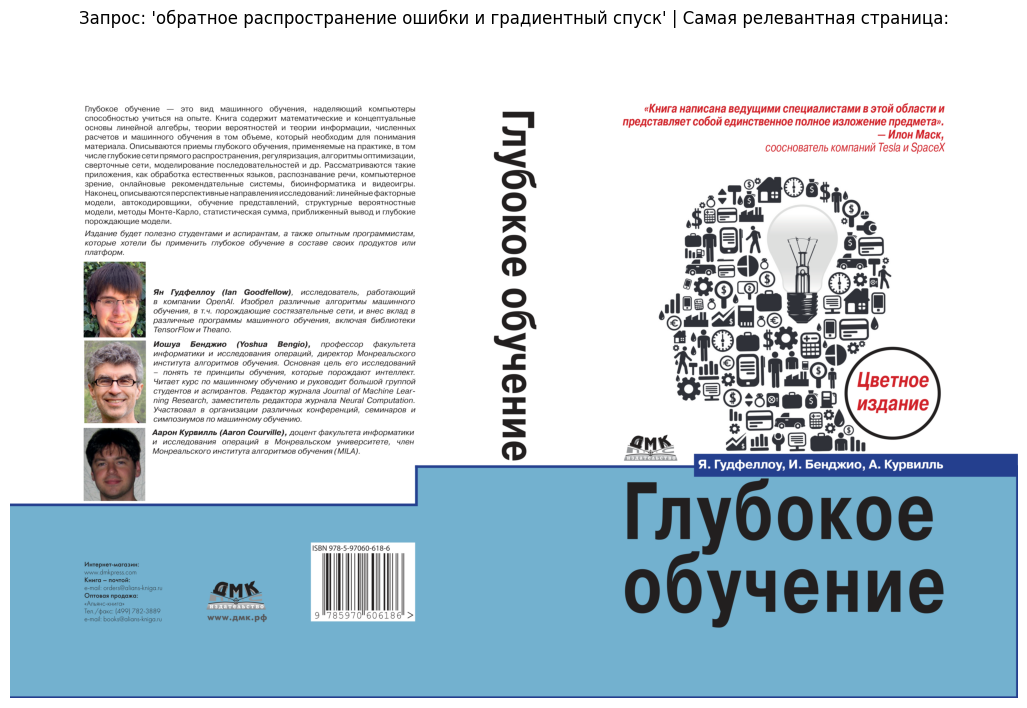

In [39]:
import fitz

# Открыть PDF и загрузить целевую страницу
pdf_path = "Глубокое обучение.pdf"
doc = fitz.open(pdf_path)
page = doc.load_page(0)

# Получить изображение страницы
img = page.get_pixmap(dpi=300)

# Опционально: сохранить изображение
# img.save("output_filename.png")
doc.close()

# Преобразовать Pixmap в массив numpy
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Отобразить изображение через Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Запрос: '{query}' | Самая релевантная страница:")
plt.axis('off')
plt.show()

 Отлично! Теперь мы можем провести дополнительное исследование, если захотим.  

Этот рабочий процесс можно повторить для **любого запроса** в нашем учебнике.  
И он также работает с **другими типами данных**:  
- Документы поддержки клиентов.  
- Переписки по электронной почте.  
- Корпоративные планы.
- Старые дневниковые записи.  
- *Почти для всего!*  

**Рабочий процесс одинаков:**  
1. Загрузка документов → разделение на фрагменты → создание эмбеддингов.  
2. Формирование запроса → создание эмбеддинга запроса → сравнение с эмбеддингами фрагментов.  

И мы получаем релевантные материалы **вместе с их источниками**!  

Это этап **поиска** в RAG (Retrieval Augmented Generation).  

Прежде чем перейти к следующим шагам, кратко обсудим **метрики сходства**.

### Меры сходства: скалярное произведение и косинусная близость  

Давайте обсудим методы сравнения векторов, а именно векторов эмбеддингов — числовых представлений данных с направлением и величиной в многомерном пространстве (в нашем случае размерность векторов — 768).  

Два самых распространенных метода:  
- **Скалярное произведение (Dot Product)**  
- **Косинусная близость или косинусное сходство (Cosine Similarity)**  

Они похожи, но есть ключевое отличие: косинусная близость включает **нормализацию**.  

| Мера сходства | Описание | Код |  
| ----- | ----- | ----- |  
| **[Скалярное произведение](https://ru.wikipedia.org/wiki/Скалярное_произведение)** | - Учитывает **направление** и **величину** векторов.<br>- Векторы, направленные в одну сторону и с большей величиной, дают положительные значения.<br>- Противоположные векторы — отрицательные. | [`torch.dot`](https://pytorch.org/docs/stable/generated/torch.dot.html), [`np.dot`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html), [`sentence_transformers.util.dot_score`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.dot_score) |  
| **[Косинусная близость](https://ru.wikipedia.org/wiki/Косинусное_сходство)** | - Векторы **нормализуются** (приводятся к единичной длине с помощью [евклидовой нормы](https://ru.wikipedia.org/wiki/Норма_(математика))), чтобы сравнивать их по направлению.<br>- Совпадающие направления: значение близко к **1**.<br>- Противоположные направления: значение близко к **-1**. | [`torch.nn.functional.cosine_similarity`](https://pytorch.org/docs/stable/generated/torch.nn.functional.cosine_similarity.html), [`1 - scipy.spatial.distance.cosine`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cosine.html), [`sentence_transformers.util.cos_sim`](https://www.sbert.net/docs/package_reference/util.html#sentence_transformers.util.cos_sim) |  

**Для текста** обычно используют **косинусную близость**, так как важно семантическое направление, а не величина.  

В нашем случае модель `all-mpnet-base-v2` (см. [Hugging Face model card](https://huggingface.co/sentence-transformers/all-mpnet-base-v2#usage-huggingface-transformers)) выдает **нормализованные эмбеддинги**, поэтому скалярное произведение и косинусная близость дают одинаковые результаты. Однако скалярное произведение работает быстрее, так как не требует нормализации.  

**Пример:**  
```python  
# Для нормализованных векторов:  
cos_sim = dot_product  # результаты совпадают  
```  

> **Важно:** Меры сходства применимы к любым эмбеддингам — текстовым, изображений, аудио. Например, модель [CLIP](https://github.com/mlfoundations/open_clip) позволяет сравнивать эмбеддинги текста и изображений.

In [40]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Получить евклидову норму (L2) для каждого вектора (убирает величину, сохраняет направление)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Примеры векторов
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Вычисление скалярного произведения
print("Скалярное произведение vector1 и vector2:", dot_product(vector1, vector2))
print("Скалярное произведение vector1 и vector3:", dot_product(vector1, vector3))
print("Скалярное произведение vector1 и vector4:", dot_product(vector1, vector4))

# Вычисление косинусного сходства
print("Косинусное сходство vector1 и vector2:", cosine_similarity(vector1, vector2))
print("Косинусное сходство vector1 и vector3:", cosine_similarity(vector1, vector3))
print("Косинусное сходство vector1 и vector4:", cosine_similarity(vector1, vector4))

Скалярное произведение vector1 и vector2: tensor(14.)
Скалярное произведение vector1 и vector3: tensor(32.)
Скалярное произведение vector1 и vector4: tensor(-14.)
Косинусное сходство vector1 и vector2: tensor(1.0000)
Косинусное сходство vector1 и vector3: tensor(0.9746)
Косинусное сходство vector1 и vector4: tensor(-1.0000)


**Результаты сравнения:**  

- **`vector1` и `vector2`**: Оба метода дают положительные значения (14 для скалярного произведения и 1.0 для косинусной близости).  
- **`vector1` и `vector4`**: Результаты отрицательные, так как `vector4` — противоположная версия `vector1`.  
- **`vector1` и `vector3`**:  
  - **Скалярное произведение** (32) больше, чем для `vector1` и `vector2` (14), так как учитывает величину векторов.  
  - **Косинусная близость** (~0.974) близка к 1, но не равна ей из-за нормализации.  

**Почему косинусная близость лучше для текста?**  
Она фокусируется на **направлении** векторов, а не на их длине, что лучше отражает семантическую близость.  

**Особенность модели `all-mpnet-base-v2`:**  
Она возвращает **нормализованные эмбеддинги**, поэтому скалярное произведение и косинусная близость дают одинаковые результаты. Но скалярное произведение работает быстрее.  

**Следующий шаг:**  
Оформим этапы семантического поиска в функцию для удобства.  

### Организация семантического поиска в виде функций  

Объединим все этапы семантического поиска, описанные выше, в одну или несколько функций для удобства повторного использования.  

In [41]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Преобразует запрос в эмбеддинг с помощью модели и возвращает топ-k оценок и индексов из эмбеддингов.
    """

    # Преобразование запроса в эмбеддинг
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Расчет оценок через скалярное произведение
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Время расчета для {len(embeddings)} эмбеддингов: {end_time-start_time:.5f} сек.")

    # Получение топ-k результатов
    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices


def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Получает релевантные ресурсы для запроса и выводит их в порядке убывания релевантности.
    Примечание: Требуется, чтобы pages_and_chunks был отформатирован особым образом.
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Запрос: {query}\n")
    print("Результаты:")
    # Перебор оценок и индексов
    for score, index in zip(scores, indices):
        print(f"Оценка: {score:.4f}")
        # Вывод релевантного фрагмента (отсортировано по убыванию)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Вывод номера страницы для проверки
        print(f"Номер страницы: {pages_and_chunks[index]['page_number']}")
        print("\n")

Отлично! Теперь протестируем наши функции.

In [42]:
query = "методы регуляризации в глубоком обучении"

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Время расчета для 1898 эмбеддингов: 0.00013 сек.


(tensor([0.7775, 0.7696, 0.7582, 0.7484, 0.7440], device='cuda:0'),
 tensor([894, 943, 505, 351, 525], device='cuda:0'))

In [43]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Время расчета для 1898 эмбеддингов: 0.00014 сек.
Запрос: методы регуляризации в глубоком обучении

Результаты:
Оценка: 0.7775
Трудность состоит в том, что когда градиент параметров очень велик, при обновле-
нии параметров градиентного спуска параметры могут быть отброшены очень далеко
в область больших значений целевой функции, и тогда значительная часть работы,
Номер страницы: 307


Оценка: 0.7696
В большинстве подобных алгоритмов поиска гиперпараметров применяется байесовская
модель регрессии для оценки как ожидаемого значения ошибки для каждого
гиперпараметра, так и неопределенности
Номер страницы: 325


Оценка: 0.7582
Глава 7 Регуляризация в глубоком обучении Центральная проблема машинного
обучения – как создать алгоритм, который будет хорошо работать не только на
обучающих, но и на новых данных.Многие используе­ мые стратегии специально
предназначены для уменьшения ошибки тестирования, быть может, за счет увеличения
ошибки обучения.Эти стратегии известны под об- щим назван

### Расширения семантического/векторного поиска  

Мы рассмотрели пример поиска релевантных результатов с использованием векторных эмбеддингов.  
Однако этот процесс можно дополнить **традиционным поиском по ключевым словам**.  
Многие современные системы используют гибридный подход: **ключевые слова + векторный поиск**.  

**Проблема масштабирования:**  
- Для небольших данных (как в нашем примере) подходит **полный перебор** (сравнение запроса со всеми эмбеддингами).  
- Для больших наборов (миллионы/миллиарды векторов) требуется **индексирование**.  

**Индексы** упорядочивают эмбеддинги, сужая область поиска.  
*Аналогия:* Чтобы найти слово «утка» в словаре, вы открываете раздел на букву «У», а не просматриваете каждую страницу.  

**Библиотеки для индексирования:**  
- **[Faiss](https://github.com/facebookresearch/faiss)** (Facebook AI Similarity Search):  
  - Открытая библиотека для эффективного поиска в больших векторных пространствах.  
  - Реализует алгоритмы вроде **[HNSW](https://arxiv.org/abs/1603.09320)** (Иерархические Навигируемые Малые Миры), которые уравновешивают скорость и точность.  
- **[Annoy](https://github.com/spotify/annoy)** (Spotify): Еще один популярный инструмент для приближенного поиска соседей.  

**Зачем это нужно?**  
Индексы позволяют производить поиск в **огромных наборах данных** без потери производительности.  
Подробнее: [Поиск методом ближайшего соседа](https://ru.wikipedia.org/wiki/%D0%97%D0%B0%D0%B4%D0%B0%D1%87%D0%B0_%D0%BF%D0%BE%D0%B8%D1%81%D0%BA%D0%B0_%D0%B1%D0%BB%D0%B8%D0%B6%D0%B0%D0%B9%D1%88%D0%B5%D0%B3%D0%BE_%D1%81%D0%BE%D1%81%D0%B5%D0%B4%D0%B0).  

# 4. Использование библиотеки LangChain для построения векторных индексов

In [44]:
! pip uninstall langchain langchain-core langgraph-prebuilt langgraph -y
! pip install -q "langchain-core<1.0"
! pip install -q "langchain_huggingface<1.0"
! pip install -q "langchain-community<0.4"
! pip install -q "langchain<1.0"
! pip install -q faiss-cpu

Found existing installation: langchain 0.3.27
Uninstalling langchain-0.3.27:
  Successfully uninstalled langchain-0.3.27
Found existing installation: langchain-core 0.3.83
Uninstalling langchain-core-0.3.83:
  Successfully uninstalled langchain-core-0.3.83
Found existing installation: langgraph-prebuilt 0.6.5
Uninstalling langgraph-prebuilt-0.6.5:
  Successfully uninstalled langgraph-prebuilt-0.6.5
Found existing installation: langgraph 0.6.11
Uninstalling langgraph-0.6.11:
  Successfully uninstalled langgraph-0.6.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.3.27 requires langchain<1.0.0,>=0.3.26, which is not installed.
ragas 0.2.15 requires langchain, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following depend

In [45]:
from langchain.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [46]:
# Загрузка PDF
pdf_path = "Глубокое обучение.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()

# Разделим документ на части
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
texts = text_splitter.split_documents(documents)

# Создание эмбеддинг модели
hf_embeddings = HuggingFaceEmbeddings(model_name="intfloat/multilingual-e5-large")

# Создание векторного хранилища
db = FAISS.from_documents(texts, hf_embeddings)

# Сохранение индекса для последующего использования
db.save_local("faiss_index")

Теперь выполним поиск по базе данных FAISS, чтобы найти документы, наиболее похожие на заданный запрос.

In [47]:
# Если нужно загрузить сохраненный индекс
# db = FAISS.load_local("faiss_index", embeddings)

# Выполнение поиска
query = "методы регуляризации в глубоком обучении"
results = db.similarity_search(query, k=3)

# Вывод результатов
for i, result in enumerate(results):
    print(f"Результат {i+1}:")
    print(result.page_content)
    print("\n")

Результат 1:
ниям. Все такие подходы называются регуляризацией. Регуляризация – это любая 
модификация алгоритма обучения, предпринятая с  целью уменьшить его ошибку 
обобщения, не уменьшая ошибку обучения. Регуляризация – одна из важнейших тем 
машинного обучения, с которой соперничать может только оптимизация.
Из теоремы об отсутствии бесплатных завтраков вытекает, что не существует наи-
лучшего алгоритма машинного обучения и, в частности, наилучшей формы регуляри-
зации. Мы должны выбирать ту форму регуляризации, которая отвечает конкретной 
решаемой задаче. Философия глубокого обучения вообще и этой книги в частности 
состоит в том, что имеется широкий круг задач (например, все интеллектуальные за-
дачи, выполняемые людьми), которые можно эффективно решить, применяя весьма 
универсальные формы регуляризации.
5.3. Гиперпараметры и  контрольные наборы
У большинства алгоритмов машинного обучения имеются гиперпараметры, управ-


Результат 2:
Глава 7
Регуляризация 
в глубоком обучении
Ц

# 5. Использование Giga-Embeddings

In [48]:
! pip install -q gigachat langchain_gigachat

In [50]:
import os
import getpass

os.environ['GIGACHAT_API_KEY'] = getpass.getpass(prompt='GIGACHAT_API_KEY: ', stream=None)

giga_api_key = os.getenv("GIGACHAT_API_KEY", "")

GIGACHAT_API_KEY:  ········


In [51]:
from rich import print
from gigachat import GigaChat


with GigaChat(credentials=giga_api_key, scope = 'GIGACHAT_API_B2B', verify_ssl_certs=False) as giga:
    print(giga.get_models())

Models(
    x_headers={
        'x-request-id': '00db8a75-91a1-4513-8125-cddcf02ab066',
        'x-session-id': 'a0d4d08b-d740-47e6-becb-2f2a79b19ed9',
        'x-client-id': None
    },
    data=[
        Model(x_headers=None, id_='GigaChat', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-2', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-2-Max', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-2-Pro', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-Max', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-Max-preview', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-Plus', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-Pro', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-Pro-preview', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaChat-preview', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='Embeddings', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='Embeddings-2', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='EmbeddingsGigaR', object_='model', owned_by='salutedevices'),
        Model(x_headers=None, id_='GigaEmbeddings-3B-2025-09', object_='model', owned_by='salutedevices')
    ],
    object_='list'
)

In [52]:
with GigaChat(credentials=giga_api_key, scope='GIGACHAT_API_B2B', verify_ssl_certs=False) as giga:
    response = giga.embeddings(["Hello world!"])
    print(response)

Embeddings(
    x_headers={
        'x-request-id': '046e1b92-c695-490c-a3d1-b93c39febe4d',
        'x-session-id': '54bb7063-0d1e-4110-a177-94127c4f7739',
        'x-client-id': None
    },
    data=[
        Embedding(
            embedding=[
                0.45751953125,
                -0.5595703125,
                0.1884765625,
                -1.1279296875,
                1.2880859375,
                -0.87158203125,
                -0.8369140625,
                0.96240234375,
                1.6708984375,
                -0.91455078125,
                0.50146484375,
                0.58203125,
                -1.3203125,
                -1.0751953125,
                -0.85888671875,
                -0.8359375,
                0.2861328125,
                0.53466796875,
                -0.479736328125,
                0.22021484375,
                0.0189971923828125,
                -0.970703125,
                -0.50048828125,
                -1.310546875,
                -0.55224609375,
                -0.0533447265625,
                -1.251953125,
                -0.81298828125,
                -0.06463623046875,
                -1.45703125,
                0.247802734375,
                0.8740234375,
                -1.2353515625,
                -1.1943359375,
                -0.8271484375,
                1.328125,
                0.53369140625,
                0.6025390625,
                -1.26953125,
                0.8828125,
                -1.1796875,
                1.4384765625,
                -0.10748291015625,
                -1.154296875,
                -0.404296875,
                0.495849609375,
                -0.049835205078125,
                0.467529296875,
                -0.29150390625,
                0.268798828125,
                0.1773681640625,
                0.8115234375,
                -0.255126953125,
                -0.230712890625,
                -1.39453125,
                1.0478515625,
                -0.92626953125,
                -0.363525390625,
                -2.029296875,
                -0.00072479248046875,
                -0.49267578125,
                0.471923828125,
                0.63525390625,
                -0.52734375,
                -1.630859375,
                1.779296875,
                0.6806640625,
                0.05908203125,
                -1.94921875,
                0.3203125,
                -0.79150390625,
                0.4775390625,
                -0.321533203125,
                -0.02276611328125,
                -0.8798828125,
                -0.1650390625,
                0.67236328125,
                0.4140625,
                0.6171875,
                -0.9306640625,
                2.50390625,
                -0.122802734375,
                0.5322265625,
                -0.6591796875,
                0.67041015625,
                1.107421875,
                0.93310546875,
                1.0029296875,
                0.8486328125,
                0.0938720703125,
                -0.78564453125,
                0.73779296875,
                1.1484375,
                -0.3046875,
                -1.2333984375,
                -0.168701171875,
                0.97314453125,
                0.6630859375,
                0.1094970703125,
                1.0546875,
                -0.2337646484375,
                0.070068359375,
                0.92578125,
                -0.39208984375,
                -0.37841796875,
                0.477783203125,
                1.251953125,
                0.78369140625,
                0.9912109375,
                0.83544921875,
                1.2705078125,
                1.265625,
                0.861328125,
                -0.68896484375,
                -0.6455078125,
                0.2215576171875,
                -0.016082763671875,
                0.07208251953125,
                -0.52587890625,
                0.97314453125,
                0.822265625,
                

In [53]:
print('Размер вектора эмбеддинга: ', len(response.data[0].embedding))

Размер вектора эмбеддинга:  1024

In [54]:
from langchain_gigachat.embeddings import GigaChatEmbeddings


# Загрузка PDF
pdf_path = "Глубокое обучение.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()

# Разделим документ на части
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
texts = text_splitter.split_documents(documents)

# Создание эмбеддинг модели
embeddings = GigaChatEmbeddings(credentials=giga_api_key, scope='GIGACHAT_API_B2B', verify_ssl_certs=False)

# Создание векторного хранилища
db = FAISS.from_documents(texts, embeddings)

# Сохранение индекса для последующего использования
db.save_local("faiss_index")

In [55]:
# Если нужно загрузить сохраненный индекс
# db = FAISS.load_local("faiss_index", embeddings)

# Выполнение поиска
query = "методы регуляризации в глубоком обучении"
results = db.similarity_search(query, k=3)

# Вывод результатов
for i, result in enumerate(results):
    print(f"Результат {i+1}:")
    print(result.page_content)
    print("\n")

Результат 1:

Глава 7
Регуляризация 
в глубоком обучении
Центральная проблема машинного обучения – как создать алгоритм, который будет 
хорошо работать не только на обучающих, но и на новых данных. Многие используе­
мые стратегии специально предназначены для уменьшения ошибки тестирования, 
быть может, за счет увеличения ошибки обучения. Эти стратегии известны под об-
щим названием «регуляризация». В распоряжении специалиста по глубокому обуче-
нию много вариантов регуляризации. На самом деле разработка все более эффектив-
ных стратегий регуляризации – одно из основных направлений исследований в этой 
области.
В главе 5 были введены понятия обобщения, недообучения, переобучения, сме-
щения, дисперсии и регуляризации. Если вы пока незнакомы с ними, ознакомьтесь 
с главой 5, прежде чем продолжать чтение.
В этой главе мы опишем регуляризацию подробно, уделив особое внимание стра-
тегиям регуляризации глубоких моделей или моделей, которые используются в каче-
стве их строительных блоков.

Результат 2:

В этой главе мы опишем регуляризацию подробно, уделив особое внимание стра-
тегиям регуляризации глубоких моделей или моделей, которые используются в каче-
стве их строительных блоков.
В некоторых разделах этой главы речь идет о стандартных концепциях машинного 
обучения. Если вы уже знакомы с ними, можете спокойно пропустить эти разделы. 
Но большая часть главы посвящена обобщению базовых концепций на случай ней-
ронных сетей.
В разделе 5.2.2 мы определили регуляризацию как «любую модификацию алгорит-
ма обучения, предпринятую с целью уменьшить его ошибку обобщения, не уменьшая 
ошибки обучения». Существует много стратегий регуляризации. В одних налагаются 
дополнительные ограничения на модель машинного обучения, например на значе-
ния параметров. В других в целевую функцию включаются дополнительные члены, 
которые можно рассматривать как мягкие ограничения на значения параметров. 
При правильном выборе такие дополнительные ограничения и штрафы могут при-

Результат 3:

ниям. Все такие подходы называются регуляризацией. Регуляризация – это любая 
модификация алгоритма обучения, предпринятая с  целью уменьшить его ошибку 
обобщения, не уменьшая ошибку обучения. Регуляризация – одна из важнейших тем 
машинного обучения, с которой соперничать может только оптимизация.
Из теоремы об отсутствии бесплатных завтраков вытекает, что не существует наи-
лучшего алгоритма машинного обучения и, в частности, наилучшей формы регуляри-
зации. Мы должны выбирать ту форму регуляризации, которая отвечает конкретной 
решаемой задаче. Философия глубокого обучения вообще и этой книги в частности 
состоит в том, что имеется широкий круг задач (например, все интеллектуальные за-
дачи, выполняемые людьми), которые можно эффективно решить, применяя весьма 
универсальные формы регуляризации.
5.3. Гиперпараметры и  контрольные наборы
У большинства алгоритмов машинного обучения имеются гиперпараметры, управ-

# Итоги

Мы научились пользоваться моделями векторного представления текстов для семантического поиска информации -- ключевого компонента RAG систем. Далее в занятиях мы рассмотрим, как улучшить данный поиск, чтобы находить еще более релевантную информацию.